# Evaluación con Tuning — ARIMA / SARIMA / SARIMAX

**Estructura del notebook:**
- Los splits Train / Test son configurables por el usuario (fechas de inicio)
- Para ARIMA y SARIMA **no** se usan variables exógenas; para SARIMAX sí
- El tuning se realiza mediante búsqueda en grilla (*grid search*) con **walk-forward CV mensual**
- El test abarca desde `TEST_START` hasta el final del dataset
- Se comparan métricas **default vs tuneado** replicando la misma estructura del notebook de árboles

```
[────────── TRAIN ──────────][──── TEST (meses completos desde TEST_START) ────]
                              mes_1  mes_2  …  mes_N
```

> **Nota sobre validación en modelos ARIMA:**  
> A diferencia de los modelos de árboles, los modelos ARIMA/SARIMA/SARIMAX no tienen hiperparámetros
> que requieran un split de validación separado del test. El tuning se realiza con
> **walk-forward CV** directamente sobre los datos de entrenamiento (ventana expandible),
> por lo que **test = todo desde `TEST_START` en adelante**. Esto es equivalente a
> lo que en el notebook de árboles sería val+test combinados.

## 1. Imports

In [1]:
import warnings, time, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/EAFIT/SIMAT/Metro/data/

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

# pmdarima (pip install pmdarima)
try:
    from pmdarima import ARIMA
    from pmdarima import model_selection as pm_cv
    HAS_PMDARIMA = True
    print("✓ pmdarima disponible")
except ImportError:
    HAS_PMDARIMA = False
    print("✗ pmdarima no instalado — ejecutar: pip install pmdarima")

# tqdm (opcional)
try:
    from tqdm.auto import tqdm; HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    class tqdm:
        def __init__(self, iterable=None, **kw): self._it = iterable or []
        def __iter__(self): return iter(self._it)
        def set_postfix(self, **kw): pass

print("✓ Librerías base listas")

✓ pmdarima disponible
✓ Librerías base listas


## 2. Configuración global

**Ajusta aquí las fechas de los splits y los parámetros del tuning.**

| Parámetro | Descripción |
|-----------|-------------|
| `TRAIN_START` | Primer mes del entrenamiento (`'YYYY-MM'`) |
| `TEST_START` | Primer mes del test (`'YYYY-MM'`). Todo desde aquí hasta el final es test |
| `SEASONAL_M` | Periodicidad estacional (7 = semanal, 365 = anual) |
| `N_CV_FOLDS` | Meses de walk-forward CV dentro del train para el tuning |
| `CV_H` | Horizonte de predicción en días por fold de CV |

> **¿Por qué no hay `VAL_START`?**  
> En ARIMA/SARIMA/SARIMAX el tuning de hiperparámetros se hace con walk-forward CV
> directamente sobre el conjunto de entrenamiento. No se necesita un split de validación
> independiente: los folds CV actúan como validación interna. El test permanece
> completamente bloqueado hasta la evaluación final.

In [2]:
# ─── AJUSTA AQUÍ ──────────────────────────────────────────────────────────────
CSV_PATH     = 'data/features_mes_completo.csv'

TRAIN_START  = '2018-01'   # Primer mes del train (inclusive)
TEST_START   = '2024-09'   # Primer mes del test  (todo desde aquí = test)

SEASONAL_M   = 7           # Periodicidad: 7=semanal, 30≈mensual, 365=anual
N_CV_FOLDS   = 6           # Número de folds walk-forward para tuning
CV_H         = 30          # Horizonte de predicción por fold (días)

SEED         = 42
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)

COLORS = {
    'ARIMA'  : '#1976D2',
    'SARIMA' : '#E64A19',
    'SARIMAX': '#388E3C',
}

MODELS = ['ARIMA', 'SARIMA', 'SARIMAX']

print(f"Modelos activos    : {MODELS}")
print(f"Train desde        : {TRAIN_START}")
print(f"Test desde         : {TEST_START}  (hasta fin de datos)")
print(f"Estacionalidad (m) : {SEASONAL_M}")
print(f"Folds CV tuning    : {N_CV_FOLDS}")
print(f"Horizonte CV       : {CV_H} días")

Modelos activos    : ['ARIMA', 'SARIMA', 'SARIMAX']
Train desde        : 2018-01
Test desde         : 2024-09  (hasta fin de datos)
Estacionalidad (m) : 7
Folds CV tuning    : 6
Horizonte CV       : 30 días


## 3. Carga del dataset

In [3]:
df_raw = pd.read_csv(CSV_PATH)
df_raw['Fecha'] = pd.to_datetime(df_raw['Fecha'])
df_raw = df_raw.set_index('Fecha')
df_raw.sort_index(inplace=True)

df_raw = df_raw.asfreq('D')   # frecuencia diaria (calendario)
# ──────────────────────────────────────────────────────────────

# Primeras 12 columnas: Consumo + 11 variables exógenas
df_raw = df_raw.iloc[:, :12]

# Convertir booleanos a int para statsmodels
bool_cols = df_raw.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_raw[bool_cols] = df_raw[bool_cols].astype(int)

print(f"Shape             : {df_raw.shape}")
print(f"Rango de fechas   : {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print(f"Columnas          : {df_raw.columns.tolist()}")

nulos = df_raw.isnull().sum()
nc = nulos[nulos > 0]
print(f"Columnas con nulos: {len(nc)}" + (f"\n{nc}" if len(nc) else " — ninguno"))
print(f"\nConsumo — media: {df_raw['Consumo'].mean():,.0f}  "
      f"std: {df_raw['Consumo'].std():,.0f}  "
      f"min: {df_raw['Consumo'].min():,.0f}  max: {df_raw['Consumo'].max():,.0f}")

Shape             : (2852, 12)
Rango de fechas   : 2018-03-12 → 2025-12-31
Columnas          : ['Consumo', 'dia_semana', 'mes', 'año', 'semana_año', 'es_fin_semana', 'es_festivo', 'dia_antes_festivo', 'dia_despues_festivo', 'semana_navidad', 'covid_cuarentena', 'es_mantenimiento']
Columnas con nulos: 0 — ninguno

Consumo — media: 69,212  std: 13,228  min: 19,741  max: 88,671


## 4. Definición dinámica de splits

- **Train**: desde `TRAIN_START` hasta el día anterior a `TEST_START` (solo meses completos)
- **Test**: desde `TEST_START` hasta el final del dataset (solo meses completos con ≥ 20 días)

El tuning walk-forward CV usa los últimos `N_CV_FOLDS` meses del train como folds internos.

In [4]:
def month_row_count(period, dataframe):
    """Número de días con datos en un mes dado."""
    start = pd.Timestamp(str(period) + '-01')
    end   = start + pd.offsets.MonthEnd(1)
    return len(dataframe[(dataframe.index >= start) & (dataframe.index <= end)])

# ── Filtrar por rango de interés ──────────────────────────────────────────────
train_start_ts = pd.Timestamp(TRAIN_START + '-01')
test_start_ts  = pd.Timestamp(TEST_START  + '-01')

df = df_raw[df_raw.index >= train_start_ts].copy()

# ── Meses de test: desde TEST_START hasta fin, con ≥ 20 días ─────────────────
p = test_start_ts.to_period('M')
last_period = df.index.max().to_period('M')

TEST_MONTHS = []
while p <= last_period:
    if month_row_count(p, df) >= 20:
        TEST_MONTHS.append(str(p))
    p += 1

if not TEST_MONTHS:
    raise ValueError(f"No hay meses completos de test desde {TEST_START}. "
                      "Ajusta TEST_START.")

# ── Train: todo antes del test ────────────────────────────────────────────────
train_df = df[df.index < test_start_ts]
test_df  = df[df.index >= test_start_ts]

# ── Folds CV internos (últimos N_CV_FOLDS meses del train) ───────────────────
p = (test_start_ts - pd.offsets.MonthBegin(1)).to_period('M')
CV_MONTHS = []
while len(CV_MONTHS) < N_CV_FOLDS:
    if month_row_count(p, df) >= 20:
        CV_MONTHS.insert(0, str(p))
    p -= 1

# ── Resumen ───────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"  Dataset           : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Train             : {train_df.index.min().date()} → {train_df.index.max().date()}  ({len(train_df)} días)")
print(f"  Folds CV ({N_CV_FOLDS} meses): {CV_MONTHS[0]} → {CV_MONTHS[-1]}  (dentro del train)")
print(f"  Test              : {TEST_MONTHS[0]} → {TEST_MONTHS[-1]}  ({len(TEST_MONTHS)} meses, {len(test_df)} días)")
print("=" * 60)

  Dataset           : 2018-03-12 → 2025-12-31
  Train             : 2018-03-12 → 2024-08-31  (2365 días)
  Folds CV (6 meses): 2024-03 → 2024-08  (dentro del train)
  Test              : 2024-09 → 2025-12  (16 meses, 487 días)


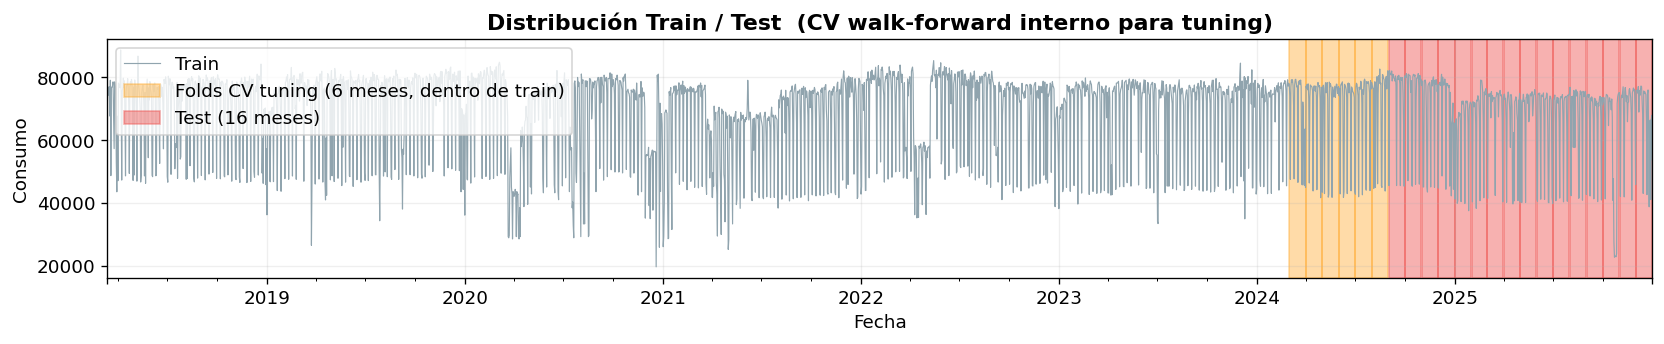

In [5]:
# ── Visualización del split ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
df['Consumo'].plot(ax=ax, lw=0.7, color='#90A4AE', label='Train')

for mes in CV_MONTHS:
    s = pd.Timestamp(f'{mes}-01')
    e = s + pd.offsets.MonthEnd(1)
    ax.axvspan(s, e, color='#FFA726', alpha=0.4)
ax.axvspan(0, 0, color='#FFA726', alpha=0.4,
           label=f'Folds CV tuning ({N_CV_FOLDS} meses, dentro de train)')

for mes in TEST_MONTHS:
    s = pd.Timestamp(f'{mes}-01')
    e = s + pd.offsets.MonthEnd(1)
    ax.axvspan(s, e, color='#EF5350', alpha=0.45)
ax.axvspan(0, 0, color='#EF5350', alpha=0.45,
           label=f'Test ({len(TEST_MONTHS)} meses)')

ax.set_title('Distribución Train / Test  (CV walk-forward interno para tuning)',
             fontweight='bold')
ax.set_ylabel('Consumo')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('split_overview_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preparación de series y variables exógenas

In [6]:
# Variable objetivo
TARGET = 'Consumo'

# Variables exógenas: todas excepto Consumo
EXOG_COLS = [c for c in df.columns if c != TARGET]

print(f"Variable objetivo : {TARGET}")
print(f"Variables exógenas ({len(EXOG_COLS)}): {EXOG_COLS}")

# Series completas
y_full  = df[TARGET]
X_full  = df[EXOG_COLS]

# Train / test
y_train = train_df[TARGET]
X_train = train_df[EXOG_COLS]

y_test  = test_df[TARGET]
X_test  = test_df[EXOG_COLS]

print(f"\nTrain: {len(y_train)} obs  |  Test: {len(y_test)} obs")

Variable objetivo : Consumo
Variables exógenas (11): ['dia_semana', 'mes', 'año', 'semana_año', 'es_fin_semana', 'es_festivo', 'dia_antes_festivo', 'dia_despues_festivo', 'semana_navidad', 'covid_cuarentena', 'es_mantenimiento']

Train: 2365 obs  |  Test: 487 obs


## 6. Funciones auxiliares

In [7]:
def compute_metrics(y_true, y_pred):
    """Calcula MAE, RMSE, MAPE y R²."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {
        'MAE'     : round(mae,  2),
        'RMSE'    : round(rmse, 2),
        'MAPE (%)': round(mape, 4),
        'R²'      : round(r2,   4),
    }


def build_model(model_name, order, seasonal_order=None):
    """
    Construye un objeto pmdarima.ARIMA con los parámetros dados.
    - ARIMA  : seasonal=False
    - SARIMA : seasonal=True, seasonal_order provisto
    - SARIMAX: seasonal=True, seasonal_order provisto (exógenas se pasan al fit)
    """
    if model_name == 'ARIMA':
        return ARIMA(order=order)
    else:  # SARIMA / SARIMAX
        return ARIMA(order=order, seasonal_order=seasonal_order)


def fit_predict_model(model_name, order, seasonal_order,
                      y_tr, X_tr, y_te, X_te):
    """
    Ajusta el modelo y retorna predicciones sobre y_te.
    Usa exógenas solo para SARIMAX.
    """
    try:
        m = build_model(model_name, order, seasonal_order)
        if model_name == 'SARIMAX':
            m.fit(y_tr, X=X_tr)
            preds = m.predict(n_periods=len(y_te), X=X_te)
        else:
            m.fit(y_tr)
            preds = m.predict(n_periods=len(y_te))
        return preds, m
    except Exception as e:
        print(f"    ⚠ Error en {model_name} {order} / {seasonal_order}: {e}")
        return np.full(len(y_te), np.nan), None


def cv_score_arima(model_name, order, seasonal_order, cv_months):
    """
    Walk-forward CV mensual dentro del train.
    Para cada mes en cv_months: entrena en todo lo anterior, predice ese mes.
    Retorna MAPE medio (métrica de tuning).
    """
    mapes = []
    for mes in cv_months:
        cutoff = pd.Timestamp(f'{mes}-01')
        end    = cutoff + pd.offsets.MonthEnd(1)
        tr  = df[(df.index < cutoff)]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 200 or len(val) == 0:
            continue
        y_tr = tr[TARGET]
        y_v  = val[TARGET]
        X_tr_cv = tr[EXOG_COLS]
        X_v_cv  = val[EXOG_COLS]
        preds, _ = fit_predict_model(model_name, order, seasonal_order,
                                     y_tr, X_tr_cv, y_v, X_v_cv)
        if not np.all(np.isnan(preds)):
            m = compute_metrics(y_v.values, preds)['MAPE (%)']
            mapes.append(m)
        else:
            mapes.append(999.0)
    return float(np.mean(mapes)) if mapes else 999.0


print("✓ Funciones auxiliares definidas.")

✓ Funciones auxiliares definidas.


## 7. Espacios de hiperparámetros y defaults

Se define una grilla de parámetros `(p, d, q)` para ARIMA/SARIMA/SARIMAX  
y `(P, D, Q)` para los modelos con componente estacional.

| Parámetro | Descripción |
|-----------|-------------|
| `p` | Orden AR (autoregresivo) |
| `d` | Orden de diferenciación |
| `q` | Orden MA (media móvil) |
| `P` | Orden AR estacional |
| `D` | Diferenciación estacional |
| `Q` | Orden MA estacional |

In [8]:
# ─── Espacio de búsqueda ──────────────────────────────────────────────────────
# Ajusta según tu capacidad de cómputo. Cada combinación requiere N_CV_FOLDS fits.

PARAM_GRID = {
    # Parámetros no estacionales — compartidos por los 3 modelos
    'p': [0, 1, 2, 3],
    'd': [0, 1],
    'q': [0, 1, 2, 3],
    # Parámetros estacionales — solo para SARIMA y SARIMAX
    'P': [0, 1, 2],
    'D': [0, 1],
    'Q': [0, 1, 2],
}

# Grillas separadas: ARIMA sin parte estacional, SARIMA/SARIMAX con parte estacional
GRID_ARIMA = list(itertools.product(
    PARAM_GRID['p'], PARAM_GRID['d'], PARAM_GRID['q']
))
GRID_SAR = list(itertools.product(
    PARAM_GRID['p'], PARAM_GRID['d'], PARAM_GRID['q'],
    PARAM_GRID['P'], PARAM_GRID['D'], PARAM_GRID['Q']
))

# Filtrado básico: evitar modelos nulos (0,0,0)
GRID_ARIMA = [(p,d,q) for p,d,q in GRID_ARIMA if p+q > 0]
GRID_SAR   = [(p,d,q,P,D,Q) for p,d,q,P,D,Q in GRID_SAR
              if (p+q > 0 or P+Q > 0)]

print(f"Combinaciones ARIMA          : {len(GRID_ARIMA)}")
print(f"Combinaciones SARIMA/SARIMAX : {len(GRID_SAR)}")
total_fits = (len(GRID_ARIMA) + 2*len(GRID_SAR)) * N_CV_FOLDS
print(f"Fits totales estimados (CV)  : {total_fits:,}")
print()
print("⚠ Si la grilla es muy grande, reduce los rangos en PARAM_GRID")
print("  o usa muestreo aleatorio (ver celda opcional al final de esta sección)")

Combinaciones ARIMA          : 30
Combinaciones SARIMA/SARIMAX : 572
Fits totales estimados (CV)  : 7,044

⚠ Si la grilla es muy grande, reduce los rangos en PARAM_GRID
  o usa muestreo aleatorio (ver celda opcional al final de esta sección)


In [9]:
# ─── Parámetros por defecto (baseline) ───────────────────────────────────────
DEFAULT_PARAMS = {
    'ARIMA': {
        'order'         : (2, 1, 2),
        'seasonal_order': None,
    },
    'SARIMA': {
        'order'         : (2, 1, 2),
        'seasonal_order': (1, 0, 1, SEASONAL_M),
    },
    'SARIMAX': {
        'order'         : (2, 1, 2),
        'seasonal_order': (1, 0, 1, SEASONAL_M),
    },
}

print("Parámetros por defecto:")
for m, p in DEFAULT_PARAMS.items():
    print(f"  {m:8s}: order={p['order']}  seasonal_order={p['seasonal_order']}")

Parámetros por defecto:
  ARIMA   : order=(2, 1, 2)  seasonal_order=None
  SARIMA  : order=(2, 1, 2)  seasonal_order=(1, 0, 1, 7)
  SARIMAX : order=(2, 1, 2)  seasonal_order=(1, 0, 1, 7)


In [10]:
# ─── (Opcional) Muestreo aleatorio para grillas grandes ──────────────────────
# Si el número de combinaciones es demasiado alto, activa esto (SAMPLE = True)
# para tomar N_SAMPLE combinaciones aleatorias de cada grilla.

SAMPLE   = True   # Cambiar a True para activar muestreo aleatorio
N_SAMPLE = 10      # Número de combinaciones aleatorias a evaluar

if SAMPLE:
    idx_a = rng.choice(len(GRID_ARIMA), min(N_SAMPLE, len(GRID_ARIMA)), replace=False)
    idx_s = rng.choice(len(GRID_SAR),   min(N_SAMPLE, len(GRID_SAR)),   replace=False)
    GRID_ARIMA = [GRID_ARIMA[i] for i in idx_a]
    GRID_SAR   = [GRID_SAR[i]   for i in idx_s]
    print(f"Muestreo activo: {len(GRID_ARIMA)} combinaciones ARIMA, "
          f"{len(GRID_SAR)} SARIMA/SARIMAX")
else:
    print("Muestreo inactivo: se evaluarán todas las combinaciones.")

Muestreo activo: 10 combinaciones ARIMA, 10 SARIMA/SARIMAX


## 8. Búsqueda de hiperparámetros (Grid Search + Walk-Forward CV)

Cada combinación `(p,d,q)` / `(p,d,q,P,D,Q)` se evalúa con walk-forward CV mensual  
dentro del conjunto de entrenamiento. Se selecciona la combinación con menor **MAPE medio**.

In [11]:
tuning_results = {}   # tuning_results[model] = DataFrame
best_params    = {}   # best_params[model]    = dict con order y seasonal_order
t0_global = time.time()

for model_name in MODELS:
    print(f"\n{'─'*60}")
    print(f"  Tuning {model_name}")
    print(f"{'─'*60}")

    grid = GRID_ARIMA if model_name == 'ARIMA' else GRID_SAR
    rows = []
    t0   = time.time()

    for i, combo in enumerate(tqdm(grid, desc=model_name)):
        if model_name == 'ARIMA':
            p, d, q = combo
            order          = (p, d, q)
            seasonal_order = None
            row = {'iter': i+1, 'p':p, 'd':d, 'q':q}
        else:
            p, d, q, P, D, Q = combo
            order          = (p, d, q)
            seasonal_order = (P, D, Q, SEASONAL_M)
            row = {'iter': i+1, 'p':p, 'd':d, 'q':q, 'P':P, 'D':D, 'Q':Q}

        score = cv_score_arima(model_name, order, seasonal_order, CV_MONTHS)
        row['cv_mape'] = score
        rows.append(row)

        if (i+1) % 10 == 0 or (i+1) == len(grid):
            best_so_far = min(r['cv_mape'] for r in rows)
            elapsed = time.time() - t0
            print(f"  combo {i+1:>4}/{len(grid)}  |  "
                  f"MAPE actual={score:.3f}%  |  "
                  f"mejor={best_so_far:.3f}%  |  "
                  f"tiempo={elapsed:.0f}s")

    df_res = (pd.DataFrame(rows)
              .sort_values('cv_mape')
              .reset_index(drop=True))
    tuning_results[model_name] = df_res

    best_row = df_res.iloc[0]
    if model_name == 'ARIMA':
        bp = {
            'order'         : (int(best_row['p']), int(best_row['d']), int(best_row['q'])),
            'seasonal_order': None,
        }
    else:
        bp = {
            'order'         : (int(best_row['p']), int(best_row['d']), int(best_row['q'])),
            'seasonal_order': (int(best_row['P']), int(best_row['D']), int(best_row['Q']), SEASONAL_M),
        }
    best_params[model_name] = bp

    print(f"\n  ✓ Mejor MAPE CV = {best_row['cv_mape']:.3f}%")
    print(f"  order={bp['order']}  seasonal_order={bp['seasonal_order']}")

print(f"\n{'='*60}")
print(f"  Tuning completado en {(time.time()-t0_global)/60:.1f} min")
print(f"{'='*60}")


────────────────────────────────────────────────────────────
  Tuning ARIMA
────────────────────────────────────────────────────────────


ARIMA:  70%|███████   | 7/10 [00:26<00:14,  4.81s/it]c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Lik

  combo   10/10  |  MAPE actual=18.663%  |  mejor=15.799%  |  tiempo=173s

  ✓ Mejor MAPE CV = 15.799%
  order=(3, 1, 3)  seasonal_order=None

────────────────────────────────────────────────────────────
  Tuning SARIMA
────────────────────────────────────────────────────────────


SARIMA:  10%|█         | 1/10 [01:57<17:34, 117.19s/it]c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum L

  combo   10/10  |  MAPE actual=9.997%  |  mejor=9.032%  |  tiempo=433s

  ✓ Mejor MAPE CV = 9.032%
  order=(3, 0, 2)  seasonal_order=(0, 1, 2, 7)

────────────────────────────────────────────────────────────
  Tuning SARIMAX
────────────────────────────────────────────────────────────


SARIMAX: 100%|██████████| 10/10 [09:50<00:00, 59.02s/it]

  combo   10/10  |  MAPE actual=14.674%  |  mejor=5.523%  |  tiempo=590s

  ✓ Mejor MAPE CV = 5.523%
  order=(1, 0, 3)  seasonal_order=(2, 1, 0, 7)

  Tuning completado en 19.9 min


## 9. Resultados del tuning — Convergencia

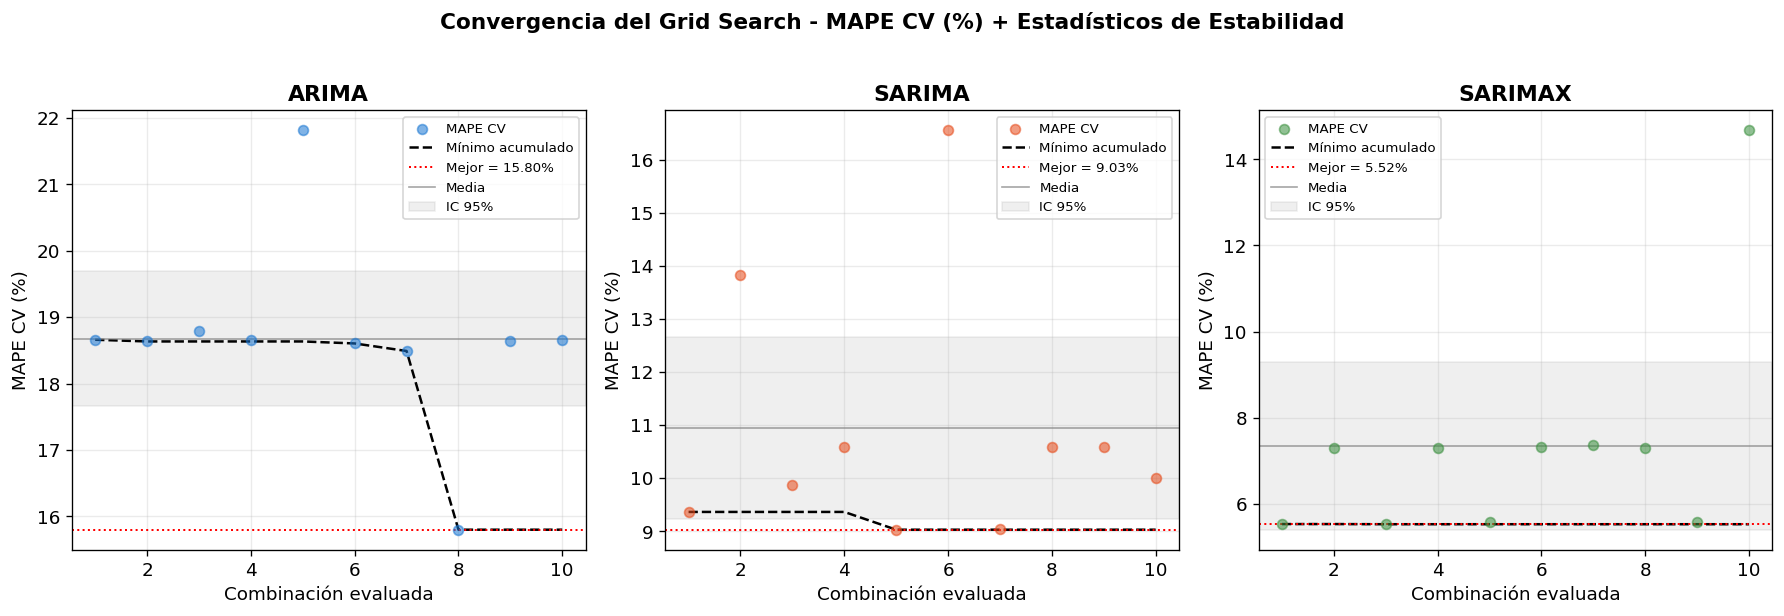


          ESTADÍSTICOS DE ESTABILIDAD POR MODELO

🔹 ARIMA
   Mejor MAPE     :  15.80%
   Media MAPE     :  18.68%
   Std. Dev.      :   1.42
   IC 95%         : [17.66, 19.69]
   Ancho IC       :  2.03  ← (menor = más estable)
   Combinaciones  : 10
   order          : (3, 1, 3)
   seasonal_order : None

🔹 SARIMA
   Mejor MAPE     :   9.03%
   Media MAPE     :  10.95%
   Std. Dev.      :   2.40
   IC 95%         : [ 9.23, 12.67]
   Ancho IC       :  3.43  ← (menor = más estable)
   Combinaciones  : 10
   order          : (3, 0, 2)
   seasonal_order : (0, 1, 2, 7)

🔹 SARIMAX
   Mejor MAPE     :   5.52%
   Media MAPE     :   7.34%
   Std. Dev.      :   2.72
   IC 95%         : [ 5.40,  9.29]
   Ancho IC       :  3.89  ← (menor = más estable)
   Combinaciones  : 10
   order          : (1, 0, 3)
   seasonal_order : (2, 1, 0, 7)

------------------------------------------------------------
Ranking por estabilidad (menor ancho de IC 95%):
  1. ARIMA    → Ancho IC = 2.034
  2. SARIMA   → Anc

In [12]:
from scipy import stats

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=False)
if len(MODELS) == 1:
    axes = [axes]

stats_summary = {}

for ax, model_name in zip(axes, MODELS):
    df_res = tuning_results[model_name].sort_values('iter').copy()
    mape_values = df_res['cv_mape'].values
    
    # Estadísticos
    mean_mape = mape_values.mean()
    std_mape = mape_values.std(ddof=1)
    n = len(mape_values)
    
    # Intervalo de Confianza 95% (t-student)
    if n > 1:
        se = std_mape / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci_lower = mean_mape - t_crit * se
        ci_upper = mean_mape + t_crit * se
        ci_width = ci_upper - ci_lower
    else:
        ci_lower = ci_upper = mean_mape
        ci_width = 0
    
    stats_summary[model_name] = {
        'mean': mean_mape,
        'std': std_mape,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'ci_width': ci_width,
        'n': n
    }
    
    # Gráfica principal
    ax.scatter(df_res['iter'], mape_values,
               color=COLORS[model_name], alpha=0.55, s=35, zorder=3, label='MAPE CV')
    
    # Mínimo acumulado
    ax.plot(df_res['iter'], df_res['cv_mape'].cummin(),
            'k--', lw=1.5, label='Mínimo acumulado')
    
    # Mejor valor
    best = df_res['cv_mape'].min()
    ax.axhline(best, color='red', lw=1.2, ls=':', label=f'Mejor = {best:.2f}%')
    
    # Media ± IC 95% (líneas suaves)
    ax.axhline(mean_mape, color='gray', lw=1.0, alpha=0.7, ls='-', label='Media')
    ax.axhspan(ci_lower, ci_upper, color='gray', alpha=0.12, label='IC 95%')
    
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('Combinación evaluada')
    ax.set_ylabel('MAPE CV (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Convergencia del Grid Search - MAPE CV (%) + Estadísticos de Estabilidad',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tuning_convergencia_arima.png', dpi=180, bbox_inches='tight')
plt.show()

# ==================== RESUMEN ESTADÍSTICO ====================
print("\n" + "="*70)
print("          ESTADÍSTICOS DE ESTABILIDAD POR MODELO")
print("="*70)

for model_name in MODELS:
    s = stats_summary[model_name]
    best = tuning_results[model_name]['cv_mape'].min()
    bp = best_params[model_name]
    
    print(f"\n🔹 {model_name}")
    print(f"   Mejor MAPE     : {best:6.2f}%")
    print(f"   Media MAPE     : {s['mean']:6.2f}%")
    print(f"   Std. Dev.      : {s['std']:6.2f}")
    print(f"   IC 95%         : [{s['ci_lower']:5.2f}, {s['ci_upper']:5.2f}]")
    print(f"   Ancho IC       : {s['ci_width']:5.2f}  ← (menor = más estable)")
    print(f"   Combinaciones  : {s['n']}")
    print(f"   order          : {bp['order']}")
    print(f"   seasonal_order : {bp.get('seasonal_order', 'N/A')}")

# Orden por estabilidad (ancho del IC)
print("\n" + "-"*60)
print("Ranking por estabilidad (menor ancho de IC 95%):")
stability_rank = sorted(stats_summary.items(), key=lambda x: x[1]['ci_width'])
for rank, (model_name, s) in enumerate(stability_rank, 1):
    print(f"  {rank}. {model_name:8s} → Ancho IC = {s['ci_width']:.3f}")

## 10. Evaluación final en test

Para cada mes de test se re-entrena el modelo con **todo el train anterior a ese mes**  
(ventana expandible). Se evalúan dos variantes:
1. **Default** — parámetros base definidos en la sección 7
2. **Tuneado** — mejores parámetros del grid search

In [13]:
def eval_all_months(params_dict, label=''):
    """
    Para cada mes de test, entrena en todo lo anterior y evalúa.
    params_dict: {model_name: {'order': ..., 'seasonal_order': ...}}
    Retorna dict results[mes][modelo] = {preds, real, dates, metrics, model}
    """
    res = {}
    for mes_test in TEST_MONTHS:
        cutoff = pd.Timestamp(f'{mes_test}-01')
        end    = cutoff + pd.offsets.MonthEnd(1)
        tr     = df[df.index < cutoff]
        te     = df[(df.index >= cutoff) & (df.index <= end)]

        y_tr = tr[TARGET]
        X_tr = tr[EXOG_COLS]
        y_te = te[TARGET]
        X_te = te[EXOG_COLS]

        res[mes_test] = {}
        for model_name, bp in params_dict.items():
            preds, model = fit_predict_model(
                model_name, bp['order'], bp['seasonal_order'],
                y_tr, X_tr, y_te, X_te
            )
            if np.all(np.isnan(preds)):
                metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE (%)': np.nan, 'R²': np.nan}
            else:
                metrics = compute_metrics(y_te.values, preds)
            res[mes_test][model_name] = {
                'preds'  : preds,
                'real'   : y_te.values,
                'dates'  : y_te.index,
                'metrics': metrics,
                'model'  : model,
            }
        print(f"  ✓ {mes_test} evaluado ({label})")
    return res


print("Evaluando con parámetros por defecto…")
results_default = eval_all_months(
    {m: DEFAULT_PARAMS[m] for m in MODELS}, label='default')

print("\nEvaluando con parámetros tuneados…")
results_tuned = eval_all_months(best_params, label='tuned')

print("\n✓ Evaluación completa.")

Evaluando con parámetros por defecto…


c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ 2024-09 evaluado (default)


c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ 2024-10 evaluado (default)
  ✓ 2024-11 evaluado (default)
  ✓ 2024-12 evaluado (default)


...

  ✓ 2025-10 evaluado (tuned)


c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ 2025-11 evaluado (tuned)


c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oscar\Desktop\University\SIMAT\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ 2025-12 evaluado (tuned)

✓ Evaluación completa.


## 11. Predicción vs Real — parámetros tuneados

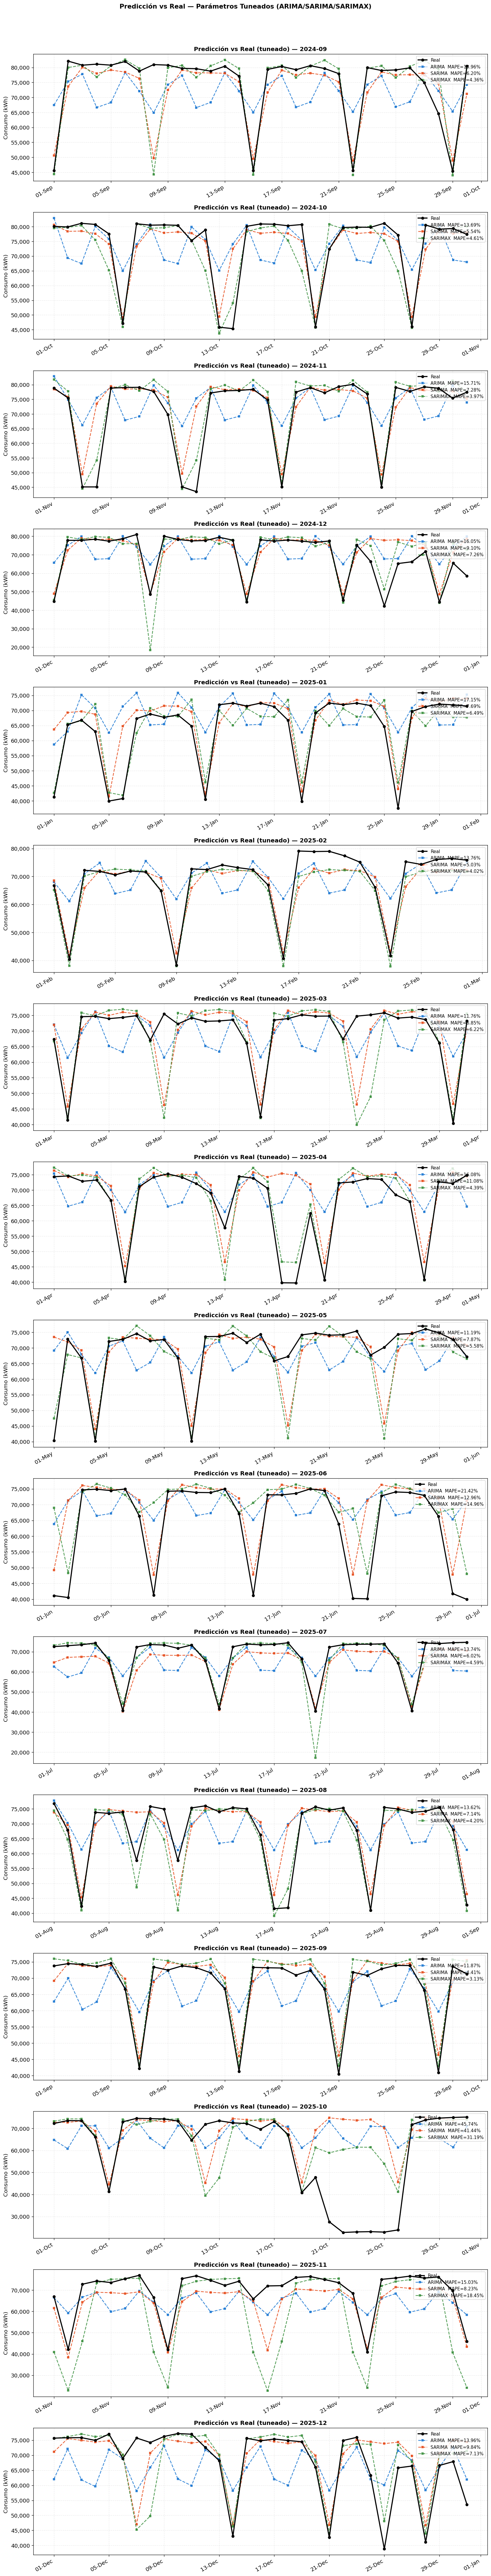

In [14]:
n = len(TEST_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5*n), sharex=False)
if n == 1:
    axes = [axes]

for ax, mes in zip(axes, TEST_MONTHS):
    dates = results_tuned[mes][MODELS[0]]['dates']
    real  = results_tuned[mes][MODELS[0]]['real']
    ax.plot(dates, real, 'k-o', lw=2.2, ms=5, label='Real', zorder=6)

    for model_name in MODELS:
        p    = results_tuned[mes][model_name]['preds']
        mape = results_tuned[mes][model_name]['metrics']['MAPE (%)']
        lbl  = f"{model_name}  MAPE={mape:.2f}%" if not np.isnan(mape) else f"{model_name}  error"
        ax.plot(dates, p, '--s', ms=4, lw=1.6,
                color=COLORS[model_name], alpha=0.85, label=lbl)

    ax.set_title(f'Predicción vs Real (tuneado) — {mes}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumo (kWh)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25, ls='--')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Predicción vs Real — Parámetros Tuneados (ARIMA/SARIMA/SARIMAX)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_real_tuned_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Degradación del error con el horizonte — parámetros tuneados

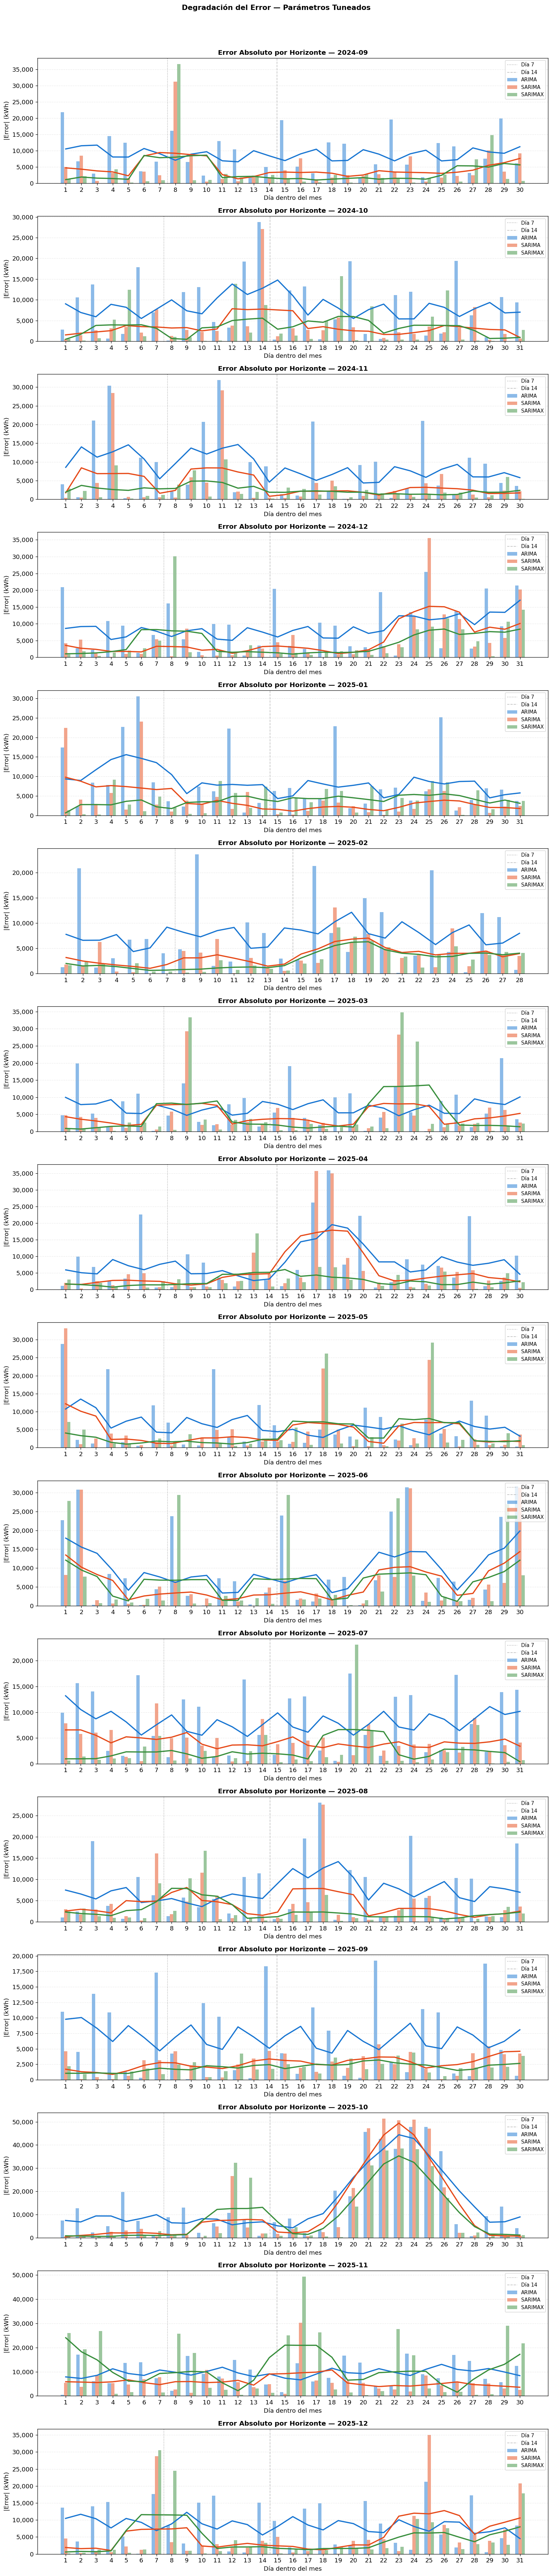

In [15]:
n = len(TEST_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.0*n))
if n == 1:
    axes = [axes]

BAR_W   = 0.65 / max(len(MODELS), 1)
offsets = {m: (i-(len(MODELS)-1)/2)*BAR_W for i, m in enumerate(MODELS)}

for ax, mes in zip(axes, TEST_MONTHS):
    real = results_tuned[mes][MODELS[0]]['real']
    dias = np.arange(1, len(real)+1)

    for model_name in MODELS:
        preds  = results_tuned[mes][model_name]['preds']
        errors = np.abs(real - preds)
        ax.bar(dias + offsets[model_name], errors,
               width=BAR_W, color=COLORS[model_name], alpha=0.5,
               label=model_name)
        trend = pd.Series(errors).rolling(5, center=True, min_periods=1).mean()
        ax.plot(dias, trend, '-', lw=2.2, color=COLORS[model_name])

    ax.axvline(7.5,  color='gray', lw=1.1, ls=':',  alpha=0.7, label='Día 7')
    ax.axvline(14.5, color='gray', lw=1.1, ls='--', alpha=0.5, label='Día 14')
    ax.set_title(f'Error Absoluto por Horizonte — {mes}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Día dentro del mes')
    ax.set_ylabel('|Error| (kWh)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.25, ls='--')
    ax.set_xticks(dias)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Degradación del Error — Parámetros Tuneados',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_horizonte_tuned_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Tabla comparativa — Default vs Tuneado

`Δ MAPE` negativo = mejora tras el tuning.

In [16]:
rows_def, rows_tun = [], []

for mes in TEST_MONTHS:
    for model_name in MODELS:
        for tag, res in [('Default', results_default), ('Tuned', results_tuned)]:
            m = res[mes][model_name]['metrics']
            (rows_def if tag == 'Default' else rows_tun).append({
                'Mes'     : mes,
                'Modelo'  : model_name,
                'MAE'     : m['MAE'],
                'RMSE'    : m['RMSE'],
                'MAPE (%)': m['MAPE (%)'],
                'R²'      : m['R²'],
            })

df_def = pd.DataFrame(rows_def).set_index(['Mes', 'Modelo'])
df_tun = pd.DataFrame(rows_tun).set_index(['Mes', 'Modelo'])

df_delta          = df_tun - df_def
df_delta.columns  = [f'Δ {c}' for c in df_delta.columns]

print("\n══ MÉTRICAS DEFAULT ════════════════════════════════════════════")
print(df_def.to_string())

print("\n══ MÉTRICAS TUNEADAS ═══════════════════════════════════════════")
print(df_tun.to_string())

print("\n══ DELTA (Tuned − Default; negativo = mejora en MAE/RMSE/MAPE) ══")
print(df_delta.to_string())

print("\n── Promedio sobre meses de test ────────────────────────────────")
print("DEFAULT:")
print(df_def.groupby('Modelo').mean().round(2).to_string())
print("\nTUNED:")
print(df_tun.groupby('Modelo').mean().round(2).to_string())


══ MÉTRICAS DEFAULT ════════════════════════════════════════════
                      MAE      RMSE  MAPE (%)      R²
Mes     Modelo                                       
2024-09 ARIMA     9653.63  11898.08   15.5631 -0.0107
        SARIMA    4238.56   7096.59    6.1180  0.6404
        SARIMAX   8796.17  10863.62   13.4220  0.1574
2024-10 ARIMA     9387.71  12361.27   15.7953  0.0086
        SARIMA    3513.21   6010.10    5.8744  0.7656
        SARIMAX  15728.15  18087.39   20.4480 -1.1227
2024-11 ARIMA     9021.42  13552.02   17.0832 -0.0471
        SARIMA    3878.20   7458.69    7.1423  0.6828
        SARIMAX   8694.01  10601.65   12.7795  0.3592
2024-12 ARIMA     9956.08  13441.23   18.2856 -0.0763
        SARIMA    5287.83   8735.72    9.0003  0.5454
        SARIMAX  11239.89  13247.00   18.4123 -0.0454
2025-01 ARIMA     7884.05  12257.61   16.8281 -0.0522
        SARIMA    4076.91   6883.43    7.6260  0.6682
        SARIMAX  13382.73  16263.13   19.6916 -0.8522
2025-02 ARIMA   

## 14. Comparativa visual — Default vs Tuneado (MAPE %)

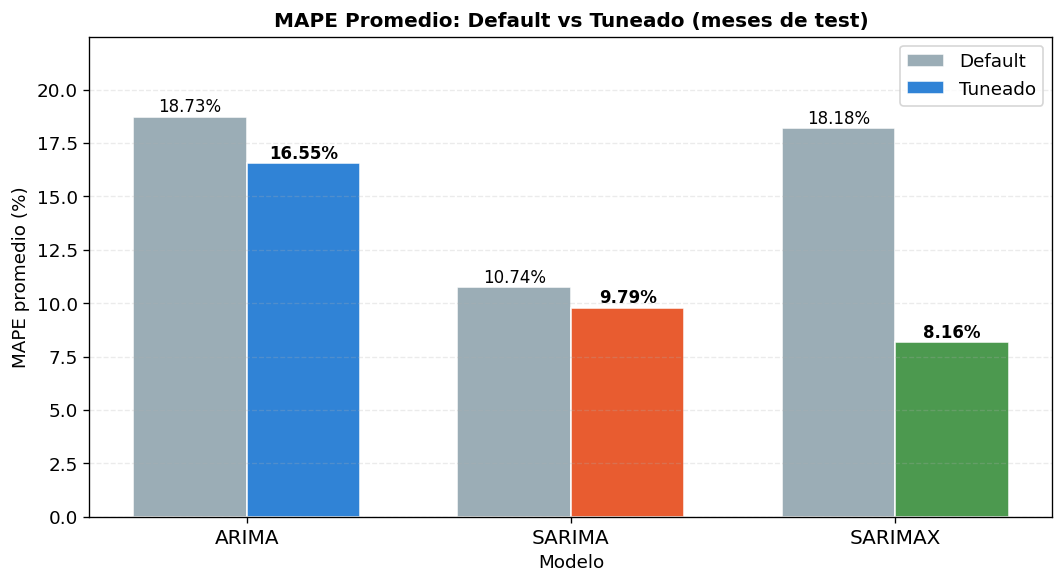

In [17]:
avg_def = df_def.groupby('Modelo')['MAPE (%)'].mean()
avg_tun = df_tun.groupby('Modelo')['MAPE (%)'].mean()

x = np.arange(len(MODELS))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [avg_def.get(m, np.nan) for m in MODELS], w,
            label='Default', color='#90A4AE', edgecolor='white', alpha=0.9)
b2 = ax.bar(x + w/2, [avg_tun.get(m, np.nan) for m in MODELS], w,
            label='Tuneado', color=[COLORS[m] for m in MODELS],
            edgecolor='white', alpha=0.9)

for bar in b1:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.05,
                f'{h:.2f}%', ha='center', va='bottom', fontsize=10)
for bar in b2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.05,
                f'{h:.2f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=12)
ax.set_ylabel('MAPE promedio (%)')
ax.set_xlabel('Modelo')
ax.set_title('MAPE Promedio: Default vs Tuneado (meses de test)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.25, ls='--')
vals = [v for v in list(avg_def) + list(avg_tun) if not np.isnan(v)]
ax.set_ylim(0, max(vals)*1.2 if vals else 10)
plt.tight_layout()
plt.savefig('default_vs_tuned_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Heatmap MAPE — parámetros tuneados

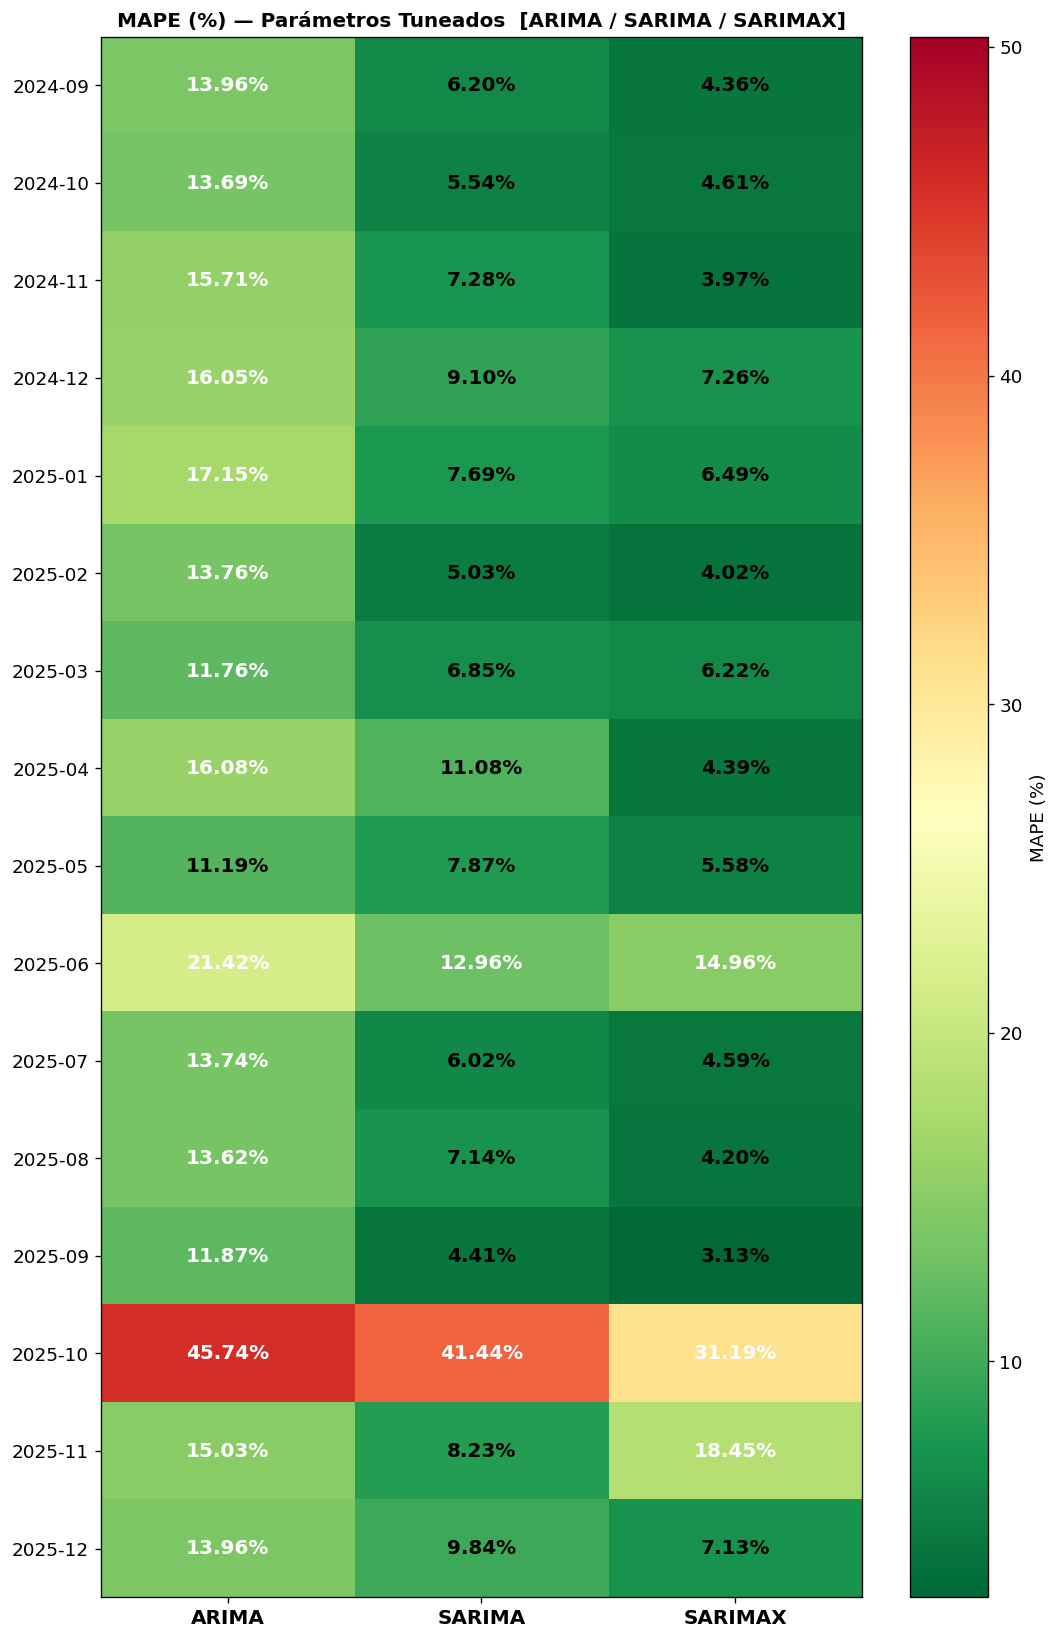

In [18]:
mape_pivot = df_tun['MAPE (%)'].unstack('Modelo')

fig, ax = plt.subplots(figsize=(9, max(3, len(TEST_MONTHS)*0.8+1)))
vmin = np.nanmin(mape_pivot.values) * 0.9
vmax = np.nanmax(mape_pivot.values) * 1.1
im = ax.imshow(mape_pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(mape_pivot.columns)))
ax.set_yticks(range(len(mape_pivot.index)))
ax.set_xticklabels(mape_pivot.columns, fontsize=12, fontweight='bold')
ax.set_yticklabels(mape_pivot.index, fontsize=11)

mean_val = np.nanmean(mape_pivot.values)
for i in range(len(mape_pivot.index)):
    for j in range(len(mape_pivot.columns)):
        v = mape_pivot.values[i, j]
        txt = f'{v:.2f}%' if not np.isnan(v) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center', fontsize=12,
                fontweight='bold',
                color='white' if (not np.isnan(v) and v > mean_val) else 'black')

plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_title('MAPE (%) — Parámetros Tuneados  [ARIMA / SARIMA / SARIMAX]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_mape_tuned_arima.png', dpi=150, bbox_inches='tight')
plt.show()

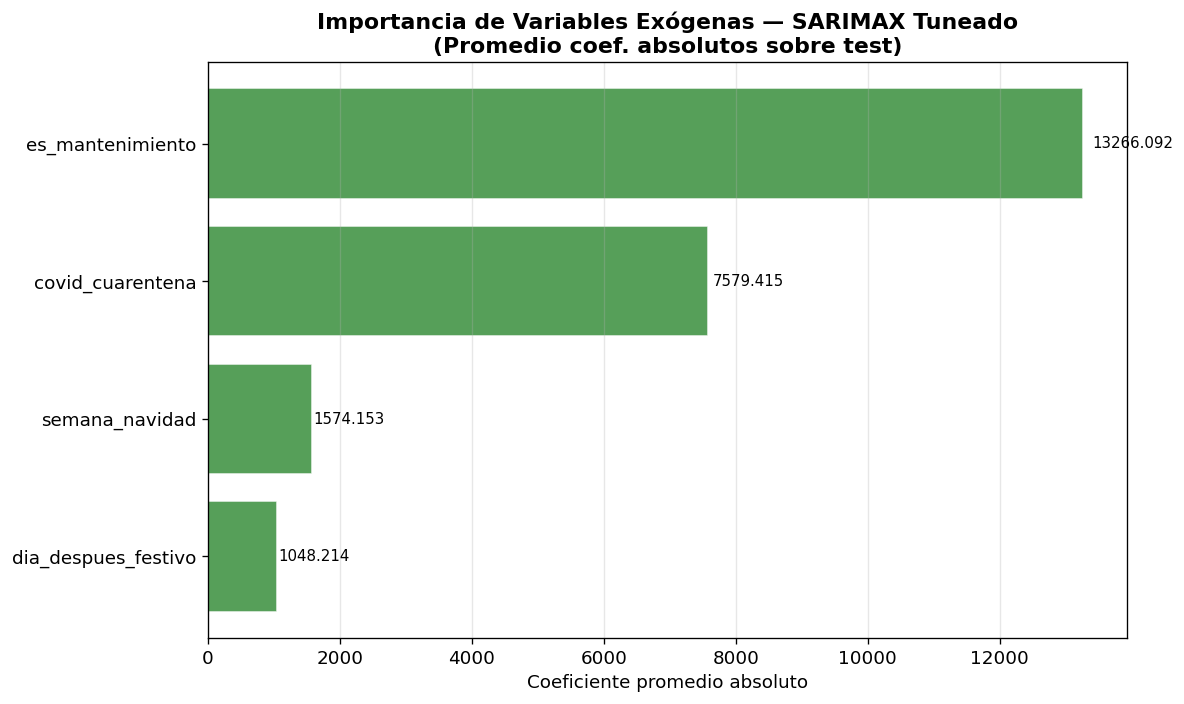

In [ ]:
if 'SARIMAX' in MODELS:
    # Solo SARIMAX usa variables exógenas. Extraemos coeficientes promedio
    exog_cols = [col for col in df.columns if col != 'Consumo']
    coef_list = []
    for mes in TEST_MONTHS:
        model = results_tuned[mes]['SARIMAX']['model']
        if hasattr(model, 'arima_res_') and hasattr(model.arima_res_, 'params'):
            exog_params = model.arima_res_.params[-len(exog_cols):] if 'exog_cols' in locals() else []
            coef_list.append(pd.Series(exog_params, index=exog_cols))
    
    if coef_list:
        avg_coef = pd.concat(coef_list, axis=1).mean(axis=1).abs().nlargest(15).sort_values()
        
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(avg_coef.index, avg_coef.values, 
                       color=COLORS['SARIMAX'], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, avg_coef.values):
            ax.text(v * 1.01, bar.get_y() + bar.get_height()/2, 
                    f'{v:.3f}', va='center', fontsize=9)
        
        ax.set_title('Importancia de Variables Exógenas — SARIMAX Tuneado\n(Promedio coef. absolutos sobre test)',
                     fontweight='bold')
        ax.set_xlabel('Coeficiente promedio absoluto')
        ax.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig('feature_importance_sarimax.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("No se encontraron coeficientes exógenos para SARIMAX.")

## 16. APE promedio por horizonte — todos los meses de test

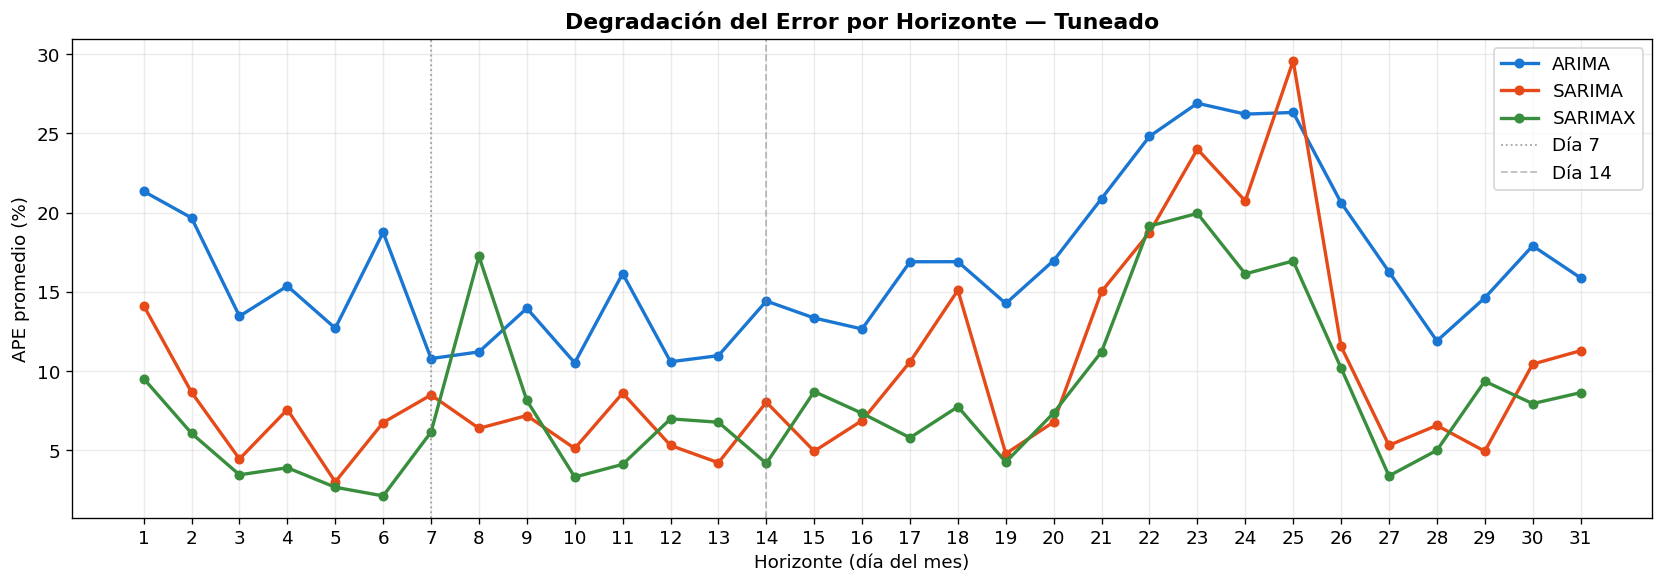

In [21]:
records = []
for mes in TEST_MONTHS:
    real = results_tuned[mes][MODELS[0]]['real']
    for model_name in MODELS:
        preds = results_tuned[mes][model_name]['preds']
        for i, (err, rv) in enumerate(zip(np.abs(real - preds), real)):
            records.append({
                'Horizonte': i+1,
                'Modelo'   : model_name,
                'APE'      : err/rv*100 if rv != 0 else np.nan,
            })

ape_df    = pd.DataFrame(records)
ape_pivot = ape_df.groupby(['Horizonte', 'Modelo'])['APE'].mean().unstack('Modelo')

fig, ax = plt.subplots(figsize=(14, 5))
for model_name in MODELS:
    if model_name in ape_pivot.columns:
        ax.plot(ape_pivot.index, ape_pivot[model_name],
                '-o', ms=5, lw=2, color=COLORS[model_name], label=model_name)

ax.axvline(7,  color='gray', lw=1.1, ls=':',  alpha=0.7, label='Día 7')
ax.axvline(14, color='gray', lw=1.1, ls='--', alpha=0.5, label='Día 14')
ax.set_xlabel('Horizonte (día del mes)')
ax.set_ylabel('APE promedio (%)')
ax.set_title('Degradación del Error por Horizonte — Tuneado',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.25)
ax.set_xticks(ape_pivot.index)
plt.tight_layout()
plt.savefig('ape_horizonte_tuned_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Comparación directa: ARIMA vs SARIMA vs SARIMAX por mes

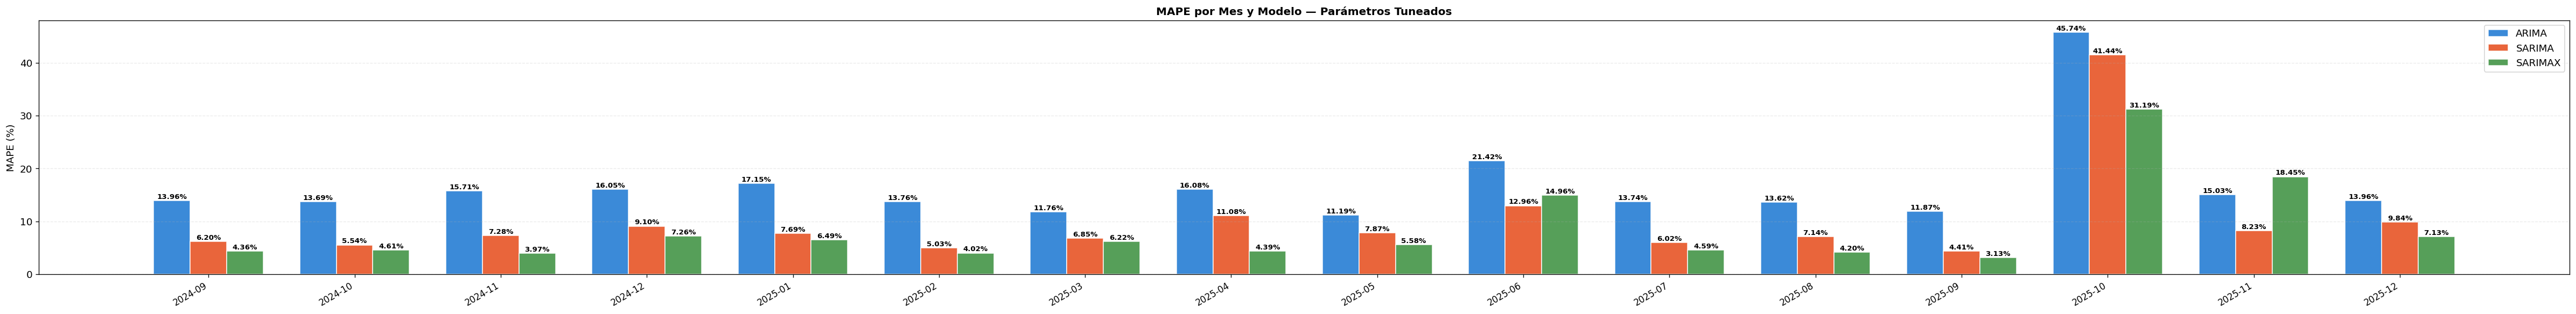

In [22]:
# Gráfico de barras agrupadas: MAPE por modelo y mes de test
mape_data = {
    model_name: [results_tuned[mes][model_name]['metrics']['MAPE (%)'] for mes in TEST_MONTHS]
    for model_name in MODELS
}

x   = np.arange(len(TEST_MONTHS))
w   = 0.25
off = np.linspace(-w, w, len(MODELS))

fig, ax = plt.subplots(figsize=(max(10, len(TEST_MONTHS)*2.5), 5))
for i, model_name in enumerate(MODELS):
    vals = mape_data[model_name]
    bars = ax.bar(x + off[i], vals, w,
                  color=COLORS[model_name], alpha=0.85,
                  label=model_name, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=8,
                    fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(TEST_MONTHS, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por Mes y Modelo — Parámetros Tuneados',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.25, ls='--')
plt.tight_layout()
plt.savefig('mape_por_mes_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Exportar resultados

In [23]:
# ── Predicciones día a día ────────────────────────────────────────────────────
all_rows = []
for mes in TEST_MONTHS:
    for model_name in MODELS:
        for tag, res in [('default', results_default), ('tuned', results_tuned)]:
            r = res[mes][model_name]
            for date, pred, real_v in zip(r['dates'], r['preds'], r['real']):
                ape = abs(real_v-pred)/real_v*100 if real_v != 0 else None
                all_rows.append({
                    'Fecha'     : date.date(),
                    'Mes'       : mes,
                    'Modelo'    : model_name,
                    'Variante'  : tag,
                    'Real'      : real_v,
                    'Prediccion': round(float(pred), 2) if not np.isnan(pred) else None,
                    'AbsError'  : round(abs(real_v - float(pred)), 2) if not np.isnan(pred) else None,
                    'APE (%)'   : round(ape, 4) if ape is not None else None,
                })

preds_df = pd.DataFrame(all_rows)
preds_df.to_csv('predicciones_tuned_arima.csv', index=False)

# ── Métricas ─────────────────────────────────────────────────────────────────
df_def_exp = df_def.copy(); df_def_exp['variante'] = 'default'
df_tun_exp = df_tun.copy(); df_tun_exp['variante'] = 'tuned'
metrics_full = pd.concat([df_def_exp, df_tun_exp]).reset_index()
metrics_full.to_csv('metricas_tuned_arima.csv', index=False)

# ── Mejores parámetros ────────────────────────────────────────────────────────
bp_serial = {
    m: {'order': list(v['order']),
        'seasonal_order': list(v['seasonal_order']) if v['seasonal_order'] else None}
    for m, v in best_params.items()
}
with open('best_params_arima.json', 'w') as f:
    json.dump(bp_serial, f, indent=2)

print("Archivos exportados:")
print("  predicciones_tuned_arima.csv  — predicciones día a día (default + tuned)")
print("  metricas_tuned_arima.csv      — MAE/RMSE/MAPE/R² para ambas variantes")
print("  best_params_arima.json        — mejores hiperparámetros encontrados")
print(f"\n{preds_df.head(8).to_string(index=False)}")

Archivos exportados:
  predicciones_tuned_arima.csv  — predicciones día a día (default + tuned)
  metricas_tuned_arima.csv      — MAE/RMSE/MAPE/R² para ambas variantes
  best_params_arima.json        — mejores hiperparámetros encontrados

     Fecha     Mes Modelo Variante        Real  Prediccion  AbsError  APE (%)
2024-09-01 2024-09  ARIMA  default 45560.17085    71880.64  26320.47  57.7708
2024-09-02 2024-09  ARIMA  default 82120.50000    74094.29   8026.21   9.7737
2024-09-03 2024-09  ARIMA  default 80773.00000    71817.67   8955.33  11.0870
2024-09-04 2024-09  ARIMA  default 81120.00000    73507.71   7612.29   9.3840
2024-09-05 2024-09  ARIMA  default 80778.50000    72179.30   8599.20  10.6454
2024-09-06 2024-09  ARIMA  default 81994.00000    73216.04   8777.96  10.7056
2024-09-07 2024-09  ARIMA  default 78793.00000    72410.67   6382.33   8.1001
2024-09-08 2024-09  ARIMA  default 80971.00000    73041.81   7929.19   9.7926
